# 2D Likelihood Contour: GW Frequency vs Pulsar Distance

This notebook generates **N** random pulsars and **M** random continuous
gravitational wave (CGW) sources, then sweeps the PTA log-likelihood over
a 2D grid of:

- **GW frequency** ($\log_{10} f_{\rm gw}$) of one CW source (x-axis)
- **Pulsar distance** (derived from `PX`, in kpc) of one target pulsar (y-axis)

`PX` is stored as parallax in mas (PINT / `types.py` convention). The sweep
iterates over `PX` in mas; the y-axis is displayed in kpc via the mapping
`d = 1 / PX_mas`. Inside `CWInjector` the same conversion is applied so
the Ellis+2012 pulsar-term phase operates on physical distance.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 42

## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [3]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            1.359724
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [4]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_mas = float(pp_tuple[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    f0 = float(pp_tuple[i].param_value("F0"))
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  "
        f"PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)  F0={f0:.1f} Hz"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1834-0701_00  PX=1.360 mas (d=0.74 kpc)  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX=0.615 mas (d=1.63 kpc)  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX=0.622 mas (d=1.61 kpc)  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX=0.481 mas (d=2.08 kpc)  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX=0.409 mas (d=2.45 kpc)  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX=0.453 mas (d=2.21 kpc)  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX=0.597 mas (d=1.67 kpc)  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX=0.460 mas (d=2.17 kpc)  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX=0.387 mas (d=2.58 kpc)  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX=1.177 mas (d=0.85 kpc)  F0=215.3 Hz

All 10 pulsars loaded.


## Set up M CW sources and inject into TOAs

We place M continuous gravitational wave sources at random sky locations with
random nHz-band GW frequencies and strain amplitude $h = 10^{-14}$.

In [5]:
TRUE_LOG10_FGW = -8.0

cw_injectors, _ = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-14.0,
)

for m, inj in enumerate(cw_injectors):
    print(
        f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
        f"gwphi={inj.param_spec['gwphi']:.3f}, "
        f"log10_fgw={inj.param_spec['log10_fgw']:.2f}"
    )

gp, config = inject_and_build_config(synthetic, cw_injectors)

# Capture the true injected value for source 0 if the swept param is frequency
if "log10_fgw" == "log10_fgw":
    TRUE_LOG10_FGW = float(cw_injectors[0].param_spec["log10_fgw"])

print(f"\nPTA config built with {M_CW_SOURCES} CW sources.")
print(f"Global params: {gp.names}")


  CW source 0: cos_gwtheta=-0.600, gwphi=0.046, log10_fgw=-7.43

PTA config built with 1 CW sources.
Global params: ('cw0_log10_h', 'cw0_cos_gwtheta', 'cw0_gwphi', 'cw0_log10_fgw', 'cw0_cos_inc', 'cw0_psi', 'cw0_phase0')


/home/hector/NYU/PTA/jax_pint/JaxPINT/jaxpint/notebook_utils.py:413: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config = PTAConfig(


## 2D likelihood sweep: log10(f_gw) vs pulsar distance

We sweep the GW frequency of CW source 0 (`cw0_log10_fgw`) and the
distance of pulsar 0 (`PX`) over a 2D grid, evaluating the PTA
log-likelihood at each point.

Note: the frequency sweep is kept narrow around the true value — moving far
off-resonance detunes the signal sharply and the likelihood collapses.

In [6]:
TARGET_PULSAR = 0
true_px_mas = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
true_distance = 1.0 / true_px_mas  # kpc
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc "
      f"(PX = {true_px_mas:.4f} mas)")
print(f"True log10(f_gw) for CW source 0: {TRUE_LOG10_FGW:.4f}")

half_window_px = 0.005           # kpc (y-axis window in distance)
half_window_fgw = 0.05           # log10 units
log10_fgw_grid = np.linspace(
    TRUE_LOG10_FGW - half_window_fgw,
    TRUE_LOG10_FGW + half_window_fgw,
    5000,
)
# Build the distance grid in kpc for the plot axis; invert to mas for the sweep
# so the likelihood (CW + astrometric parallax) receives physically correct
# parallax values.
distance_grid = np.linspace(
    true_distance - half_window_px,
    true_distance + half_window_px,
    5000,
)
px_mas_grid = 1.0 / distance_grid

def eval_logL_2d(log10_fgw_val, px_mas_val):
    gp_mod = gp.with_value("cw0_log10_fgw", log10_fgw_val)
    pp_mod_0 = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_val)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (pp_mod_0,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(gp_mod, pp_mod, config)

print(f"Computing {len(log10_fgw_grid)} x {len(px_mas_grid)} = "
      f"{len(log10_fgw_grid) * len(px_mas_grid)} likelihood evaluations...")
logL_2d = sweep_2d_logL(eval_logL_2d, log10_fgw_grid, px_mas_grid)
print("Done.")

Pulsar 0 true distance: 0.735 kpc (PX = 1.3597 mas)
True log10(f_gw) for CW source 0: -7.4262
Computing 5000 x 5000 = 25000000 likelihood evaluations...
Done.


## Colormesh plot

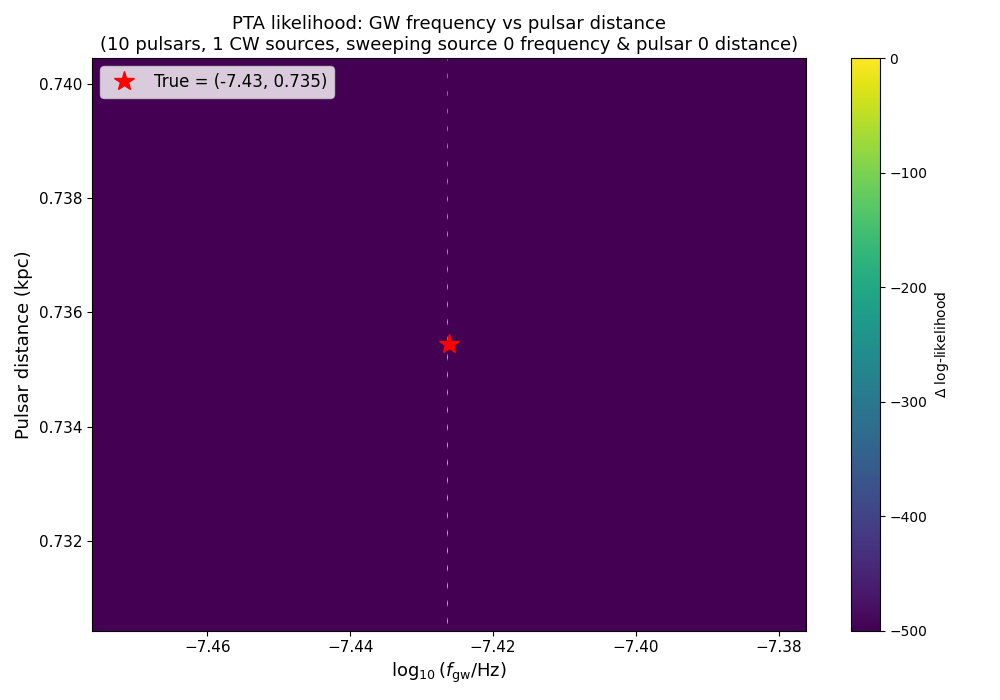

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

# logL_2d is shaped (n_y=len(px_mas_grid), n_x=len(log10_fgw_grid)) where y
# is indexed in sweep order (mas). Flip to present in kpc ascending order so
# the plot axis is monotonically increasing.
distance_grid_plot = distance_grid[::-1]
logL_2d_plot = logL_2d[::-1, :]

mesh = plot_2d_delta_logL(
    ax, log10_fgw_grid, distance_grid_plot, logL_2d_plot,
    true_xy=(TRUE_LOG10_FGW, true_distance),
)
ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/\rm Hz)$", fontsize=13)
ax.set_ylabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA likelihood: GW frequency vs pulsar distance\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, "
    f"sweeping source 0 frequency & pulsar {TARGET_PULSAR} distance)",
    fontsize=13,
)
ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## 1D likelihood sweep: log10(f_gw) at true distance

Slice through the 2D surface at the true pulsar distance to show
how the likelihood depends on GW frequency alone.

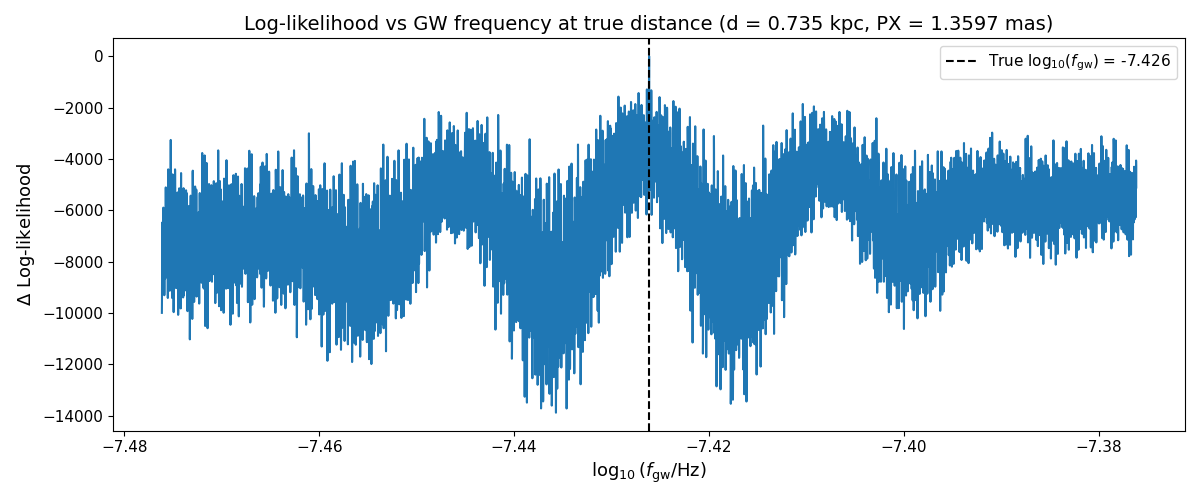

In [8]:
log10_fgw_fine = np.linspace(
    TRUE_LOG10_FGW - half_window_fgw,
    TRUE_LOG10_FGW + half_window_fgw,
    10000,
)

def _eval_1d(f, _px_mas=jnp.float64(true_px_mas)):
    return eval_logL_2d(f, _px_mas)

logL_1d = sweep_1d_logL(_eval_1d, log10_fgw_fine)
delta_1d = logL_1d - logL_1d.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log10_fgw_fine, delta_1d, linewidth=1.5)
ax.axvline(
    TRUE_LOG10_FGW, color="black", linestyle="--", linewidth=1.5,
    label=f"True log$_{{10}}(f_{{\\rm gw}})$ = {TRUE_LOG10_FGW:.3f}",
)
ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/\rm Hz)$", fontsize=13)
ax.set_ylabel(r"$\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"Log-likelihood vs GW frequency at true distance "
    f"(d = {true_distance:.3f} kpc, PX = {true_px_mas:.4f} mas)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()